# 2장. 퍼셉트론

## 2-1. 퍼셉트론이란?
- 퍼셉트론은 1957년 프랑크 로젠블라트(Frank Rosenblatt)가 고안한 알고리즘이다.
- 이 알고리즘은 신경망(딥러닝)의 기원이 되는 알고리즘이다.
- 퍼셉트론은 다수의 신호를 입력받아 하나의 신호를 출력한다.
- 퍼셉트론 신호는 '흐른다/안 흐른다(1 or 0)의 두 가지 값을 가질 수 있다.

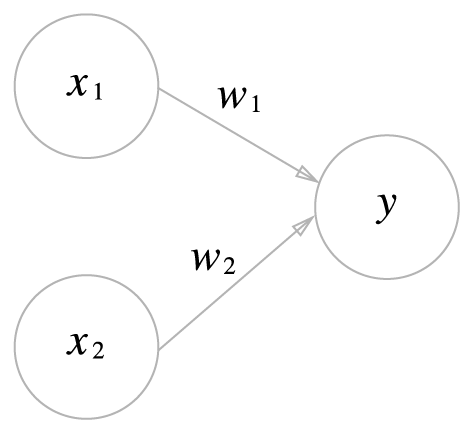
    
- ${x_1}$ 과 ${x_2}$ 는 입력 신호이고 ${y}$ 는 출력 신호 ${w_1}$ 과 ${w_2}$ 는 가중치 이다.
- 그림의 원을 노드라고 부른다. 입력 신호가 뉴런에 보내질 때는 각각 고유한 가중치가 곱해진다.
- 뉴런에서 보내온 신호의 총합이 정해진 임계값을 넘어설 때만 1을 출력한다.
  임계값은 $\theta$ 로 표시한다.
- 이상을 수식으로 나타내면 다음과 같다.

    $y = \left\{
    \begin{array}{ll}
    0 & \text{if } (w_1x_1 + w_2x_2 \leq \theta) \\
    1 & \text{if } (w_1x_1 + w_2x_2 > \theta) \\
    \end{array}
    \right.$

- 퍼셉트론은 복수의 입력 신호에 각각에 고유한 가중치를 부여한다.
- 가중치는 각 신호가 결과에 주는 영향을 조절하는 요소로 작용한다.
- 즉, 가중치가 클수록 해당 신호가 그만큼 더 중요함을 의미한다.

<br>
<br>

## 2-2. 단순한 논리 회로

### AND 게이트
|${x_1}$ | ${x_2}$ | y |
|--|--|--|
|0|0|0|
|1|0|0|
|0|1|0|
|1|1|1|
- AND 게이트를 퍼셉트론으로 표현하려면 위 진리표대로 작동하는 ${w_1}$, ${w_2}$, $\theta$ 의 값을 정하면 된다.
- 위 진리표를 만족하는 매개변수 조합은 무한히 많다. (0.5, 0.5, 0.6)일 때 ... (1.0, 1.0, 1.0)일 때 모두 AND 게이트의 조건을 만족한다.
- 왜냐하면 $1×0.5+1×0.5=0.5+0.5=1.0>0.6$ 이므로 입력이 모두 1일 때 출력이 1이 된다
 


### NAND 게이트
|${x_1}$ | ${x_2}$ | y |
|--|--|--|
|0|0|1|
|1|0|1|
|0|1|1|
|1|1|0|
- NAND 게이트는 Not AND를 의미하며, 그 동작은 AND 게이트의 출력을 뒤집은 것이다.
- 진리표로 나타내면 ${x_1}$, ${x_2}$ 가 모두 1일 때만 0을 출력한다.
- 위 진리표를 만족하는 매개변수 조합도 무수히 많다. (-0.5, -0.5, -0.6) 조합 등이 있다.


### OR 게이트
|${x_1}$ | ${x_2}$ | y |
|--|--|--|
|0|0|0|
|1|0|1|
|0|1|1|
|1|1|1|
- OR  게이트 역시 만족하는 매개변수 조합이 무수히 많다.
- (0.5, 0.5, 0.4) 조합 등이 있다.

<br>
<br>

## 2-3. 퍼셉트론 구현하기

In [4]:
# AND
def AND(x1, x2):
    w1, w2, theta = 0.5, 0.5, 0.6
    tmp = x1 * w1 + x2 * w2
    
    if tmp <= theta:
        return 0
    elif tmp > theta:
        return 1

print(AND(0, 0))
print(AND(1, 0))
print(AND(0, 1))
print(AND(1, 1))

0
0
0
1


### 가중치와 편향 도입
- 이전의 식에서 $\theta$ 를 $-b$로 치환하면 퍼셉트론의 동작을 아래 식 처럼 표현할 수 있다.
$$y = \left\{
\begin{array}{ll}
0 & \text{if } (b + w_1x_1 + w_2x_2 \leq 0) \\
1 & \text{if } (b + w_1x_1 + w_2x_2 > 0) \\
\end{array}
\right.$$
- 여기서 b 를 편향(bias)이라고 한다. 퍼셉트론은 입력 신호에 가중치를 곱한 값과 편향을 합한다.
- 그리고 그 값이 0을 넘으면 1 을 출력하고 그렇지 않으면 0을 출력한다.

In [10]:
import numpy as np

x = np.array([0,1])
w = np.array([0.5, 0.5])
b = -0.7
print(w * x)

print(np.sum(w * x))

print(np.sum(w * x) + b)  # 대략 -0.2 (부동소수점에 의한 연산 오차)

[0.  0.5]
0.5
-0.19999999999999996


- 넘파이 배열끼리 곱셈은 두 배열의 원소 수가 같다면 각 원소끼리 곱한다.
- 그래서 이 예의 $w * x$ 에서는 인덱스가 같은 원소끼리 곱한다.

In [13]:
# 가중치 편향을 도입한 AND 게이트
def AND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.7
    tmp = np.sum(w*x) + b

    if tmp <= 0:
        return 0
    else:
        return 1

print(AND(0, 0))
print(AND(1, 0))
print(AND(0, 1))
print(AND(1, 1))

0
0
0
1


In [15]:
# 가중치 편향을 도입한 AND 게이트
def NAND(x1, x2):
    x = np.array([x1, x2])
    w = np.array([-0.5, -0.5])
    b = 0.7
    tmp = np.sum(w*x) + b

    if tmp <= 0:
        return 0
    else:
        return 1

print(NAND(0, 0))
print(NAND(1, 0))
print(NAND(0, 1))
print(NAND(1, 1))

1
1
1
0


In [17]:
# 가중치 편향을 도입한 AND 게이트
def OR(x1, x2):
    x = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = -0.1
    tmp = np.sum(w*x) + b

    if tmp <= 0:
        return 0
    else:
        return 1

print(OR(0, 0))
print(OR(1, 0))
print(OR(0, 1))
print(OR(1, 1))

0
1
1
1


- 가중치 $w_1$, $w_2$ 는 입력 신호가 결과에 주는 영향력(중요도)을 조절하는 매개변수이다.
- 편향은 뉴런이 얼마나 쉽게 활성화(결과로 1을 출력) 하느냐를 조절하는 매개변수 이다.

<br>
<br>

## 2-4. 퍼셉트론의 한계
- 지금까지 살펴본 것처럼 퍼셉트론을 이용하면 AND, NAND, OR 의 3가지 논리 회로를 구현할 수 있다.
- 그러나 XOR 게이트도 퍼셉트론으로 구현할 수 없다.
|${x_1}$ | ${x_2}$ | y |
|--|--|--|
|0|0|0|
|1|0|1|
|0|1|1|
|1|1|0|
- OR 게이트는 $(b, w_1, w_2) = (-0.5, 1.0, 1.0)$ 일때 OR 게이트 진리표를 만족한다. 이때의 식은 아래와 같다.
  
    $y = \left\{
    \begin{array}{ll}
    0 & \text{if } (-0.5 + x_1 + x_2 \leq \theta) \\
    1 & \text{if } (-0.5 + x_1 + x_2 > \theta) \\
    \end{array}
    \right.$

- 위 식의 퍼셉트론은 직선으로 나뉜 두 영역을 만든다.
- 직선으로 나뉜 한쪽 영역은 1을 출력하고 다른 한쪽은 0을 출력한다.

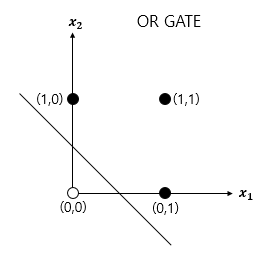

- 그러나 XOR 게이트의 경우 직선 하나로 두 영역을 나눌 수 없다.

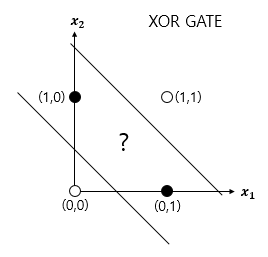

### 선형과 비선형
- 직선 하나로는 불가능하지만 '직선' 이라는 제약을 없애면 가능하다.

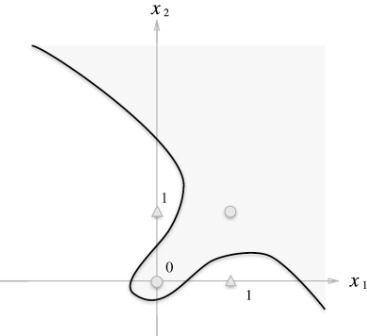

- 퍼셉트론은 직선 하나로 나눈 영역만 표현할 수 있다는 한계가 있다. 따라서 위와 같은 곡선은 표현할 수 없다.
- 덧붙여서 위와 같은 곡선 영역을 **비선형** 영역, 직선의 영역을 **선형** 영역이라고 한다.

<br>
<br>

## 2-5. 다층 퍼셉트론
- 층을 쌓아 다층 퍼셉트론을 만든 다면 XOR 게이트 문제를 해결할 수 있다.

### 기존 게이트 조합하기
- XOR 게이트를 만드는 방법은 다양하다. 그중 하나는 앞에서 만든 AND, NAND, OR 게이트를 조합하는 방법이다.

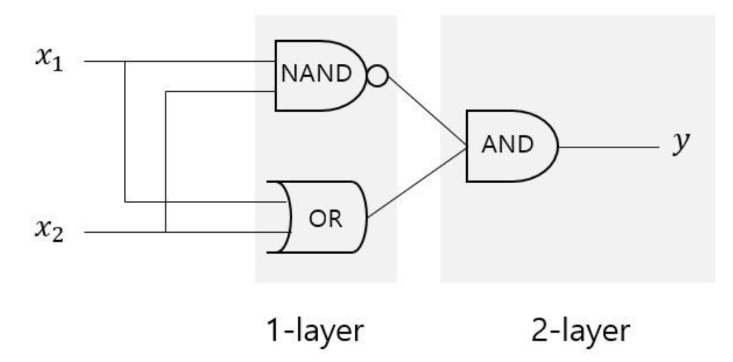

- NAND의 출력을 $s_1$, OR의 출력을 $s_2$로 해서 진리표를 만들면 아래와 같다. ($x_1, x_2, y$)에 집중하면 XOR 과 같다.
|${x_1}$ | ${x_2}$ |${s_1}$ | ${s_2}$ | y |
|--|--|--|--|--|
|0|0|1|0|0|
|1|0|1|1|1|
|0|1|1|1|1|
|1|1|0|1|0|

In [18]:
# XOR 게이트 구현하기
def XOR(x1, x2):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    y = AND(s1, s2)
    return y

print(XOR(0,0))
print(XOR(1,0))
print(XOR(0,1))
print(XOR(1,1))

0
1
1
0


- 이로써 XOR 게이트를 완성했다. 지금 구현한 XOR 게이트를 뉴런을 이용한 퍼셉트론으로 표한하면 아래와 같다.

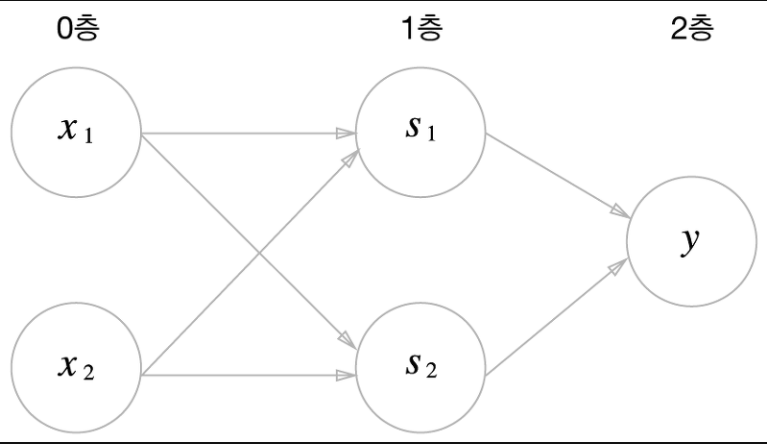


### 다층 퍼셉트론 
- 위의 퍼셉트론은 지금까지본 단층 퍼셉트론과 형태가 조금 다른 다층 퍼셉트론이다.
- 2층 퍼셉트론에서는 0층에서 1층으로 신호가 전달되고, 이어서 1층에서 2층으로 신호가 전달된다.
    - 0층의 두 뉴런이 입력 신호를 받아 1층의 뉴런으로 신호를 보낸다.
    - 1층의 뉴런이 2층의 뉴런으로 신호를 보내고, 2층의 뉴런은 y를 출력한다.
- 다층 퍼셉트론의 동작은 공장의 조립 라인에 비유할 수 있다.
- 1단(1층째) 작업자는 흘러오는 '부품'을 다듬어 일이 완료되면 2단 작업자에게 건내준다.
- 2단의 작업자는 1단의 작업자로부터 전달받은 '부품'을 다음어 완성품으로 만들어 출하(출력) 한다.
- 이처럼 2층 구조를 사용해 XOR 게이트를 구현할 수 있다. 다시말해, 단층 퍼셉트론으로는 표현하지 못한 것을 층을 하나 늘려 구현한다.

<br>
<br>

## 2-6. 퍼셉트론과 컴퓨터
- 다층 퍼셉트론은 지금까지 보아온 회로보다 복잡한 회로를 만들 수 있다. 예를 들면, 덧셈을 처리하는 가산기도 만들 수 있다.
  2진수를 10진수로 변환하는 인코더, 어떤 조건을 충족하면 1을 출력하는 회로(패리티 검사 회로)도 퍼셉트론으로 표현할 수 있다.
- 심지어 퍼셉트론으로 컴퓨터도 표현할 수 있다.
- 컴퓨터는 정보를 처리하는 기계이다. 컴퓨터에 무언가를 입력하면 정해진 방법으로 처리하고 그 결과를 출력한다.
- 정해진 방법으로 처리한다는 것은 컴퓨터도 마치 퍼셉트론처럼 입력과 출력으로 구성된 특정 규칙대로 계산을 수생한다는 뜻이다.
- 컴퓨터 내부에서 이뤄지는 처리가 매우 복잡할 것 같지만, 사실은 NAND 게이트의 조합만으로 컴퓨터가 수행하는 일을 재현할 수 있다.
- 그럼 어떤 구조의 퍼셉트론이면 컴퓨터를 표현할 수 있을까? 이론상 2층 퍼셉트론이면 컴퓨터를 만들 수 있다.
- 2층 퍼셉트론, 정확히는 비선형인 시그모이드 함수를 활성화 함수로 이용하면 임의의 함수를 표현할 수 있기 때문에 가능하다.
- 그러나 2층 퍼셉트론 구조에서 가중치를 적절히 설정하여 컴퓨터를 만들기란 너무 어렵다.
- 실제로도 NAND 등의 저수준 소자에서 시작하여 컴퓨터를 만드는 데 필요한 부품을 단계적으로 만들어나가는 것이 자연스러운 방법이다.
    - 처음에는 AND 와 OR 게이트
    - 그 다음에는 반가산기와 전가산기
    - 그 다음에는 산술 논리 연산 장치(ALU)
    - 그 다음에는 CPU 